# Ulusal Faktoring — Check Default: EDA

Goal: understand the data before building a model that predicts whether a check defaults (`target = 1`).

Sections: 1) data checks · 2) target · 3) missing values · 4) single features · 5) predictive power · 6) correlations · 7) stability over time · 8) leakage · 9) summary

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid", context="notebook")

FIG_DIR = Path("figures/eda")
FIG_DIR.mkdir(parents=True, exist_ok=True)


def save(name):
    # Key charts are exported for the presentation (Task 3).
    plt.savefig(FIG_DIR / f"{name}.png", dpi=150, bbox_inches="tight")

## 1. Data checks

In [2]:
raw = pd.read_excel("UF_DS_case.xlsx")
print(raw.shape)
raw.head()

(100000, 20)


,Unnamed: 0,ID,term,branch_segment,founder age,company age,days_due,target,risk_other_factoring,cust_tenure,drawer_interest_accumulated,amount,cust_first_offer_flag,drawer_unpaidcheckcount,drawer_unpaid_ratio,cust_late_balance,drawer_last_redflag_date,drawer_creditbureauscore,drawer_max_balance_last12m,TERM
0,0,1,202406,A,NaN,1.0,80,0,0,40,0.0,5.000000e+05,0,0.0,NaN,NaN,NaN,1796.0,2521406.0,202401
1,1,2,202505,D,NaN,17.0,89,0,6194211,1918,217208.0,2.373494e+06,0,0.0,NaN,NaN,NaN,NaN,2588845.0,202401
2,2,3,202506,A,57.0,NaN,49,0,1500000,2629,330.0,6.024096e+05,0,0.0,NaN,3327.0,NaN,NaN,9251623.0,202401
3,3,4,202507,D,37.0,NaN,37,0,0,0,372.0,3.012048e+06,1,0.0,NaN,12079.0,NaN,NaN,126915.0,202401
4,4,5,202409,A,NaN,14.0,70,0,24529632,1274,0.0,2.085692e+05,0,0.0,0.70142,NaN,NaN,NaN,18006011.0,202401


In [3]:
pd.DataFrame({
    "dtype": raw.dtypes.astype(str),
    "n_unique": raw.nunique(),
    "pct_missing": raw.isna().mean().mul(100).round(1),
    "example": raw.iloc[1],
})

,dtype,n_unique,pct_missing,example
Unnamed: 0,int64,100000,0.0,1
ID,int64,100000,0.0,2
term,int64,70,0.0,202505
branch_segment,str,4,0.0,D
founder age,float64,70,72.6,NaN
company age,float64,70,27.6,17.0
days_due,int64,421,0.0,89
target,int64,2,0.0,0
risk_other_factoring,int64,60366,0.0,6194211
cust_tenure,int64,4640,0.0,1918


In [4]:
print("'Unnamed: 0' == ID - 1 :", (raw["Unnamed: 0"] == raw["ID"] - 1).all())
print("ID is unique           :", raw["ID"].is_unique)

df = raw.drop(columns="Unnamed: 0").rename(columns={"founder age": "founder_age", "company age": "company_age"})

dup = df.drop(columns="ID").duplicated(keep=False)
print(f"Rows identical on every field except ID: {dup.sum()} "
      f"(target values: {df.loc[dup, 'target'].value_counts().to_dict()})")

'Unnamed: 0' == ID - 1 : True
ID is unique           : True
Rows identical on every field except ID: 32 (target values: {0: 32})


`Unnamed: 0` is just an old index, so I drop it. 16 pairs of rows are identical apart from ID (all paid). That's too few to matter, and they could be real separate checks, so I keep them.

### 1.1 `term` vs `TERM`
The brief only describes one period column, but the data has two.

In [5]:
issue = pd.to_datetime(df["term"].astype(str), format="%Y%m")
TERM = pd.to_datetime(df["TERM"].astype(str), format="%Y%m")

print("term range:", issue.min().date(), "->", issue.max().date(), f"({df['term'].nunique()} months)")
print("TERM range:", TERM.min().date(), "->", TERM.max().date(), f"({df['TERM'].nunique()} months)\n")

print(df.groupby("TERM")["target"].agg(n="size", default_rate="mean").T.round(4))
print(f"\nChi-square p-value, TERM vs target        : {chi2_contingency(pd.crosstab(df['TERM'], df['target']))[1]:.3f}")
print(f"Chi-square p-value, TERM vs term (year)   : {chi2_contingency(pd.crosstab(df['TERM'], df['term'] // 100))[1]:.3f}")
print(f"Share of checks issued AFTER their TERM month: {(issue > TERM).mean():.1%}")

term range: 2020-01-01 -> 2025-10-01 (70 months)
TERM range: 2024-01-01 -> 2024-10-01 (10 months)

TERM              202401      202402      202403      202404      202405      202406      202407      202408      202409      202410
n             10000.0000  10000.0000  10000.0000  10000.0000  10000.0000  10000.0000  10000.0000  10000.0000  10000.0000  10000.0000
default_rate      0.0572      0.0565      0.0582      0.0604      0.0588      0.0571      0.0615      0.0598      0.0583      0.0591

Chi-square p-value, TERM vs target        : 0.911
Chi-square p-value, TERM vs term (year)   : 0.176
Share of checks issued AFTER their TERM month: 28.0%


`TERM` has exactly 10k rows per month, isn't related to the target or the issue year (high p-values), and 28% of checks were issued after their `TERM` month. It looks like a sampling batch, so I drop it. `term` is the issue month and becomes my time axis.

In [6]:
df["issue_month"] = issue
df["issue_year"] = issue.dt.year
df = df.drop(columns="TERM")

### 1.2 `amount`

In [7]:
print(df["amount"].head(8).round(2).tolist())
for f in [1, 0.83, 0.7, 0.3]:
    scaled = df["amount"] * f
    share = (np.abs(scaled - scaled.round(-3)) < 0.5).mean()
    print(f"amount x {f:<4}: {share:5.1%} of values become a round thousand")

[500000.0, 2373493.98, 602409.64, 3012048.19, 208569.2, 3333333.33, 2333333.33, 2000000.0]
amount x 1   : 33.1% of values become a round thousand
amount x 0.83: 32.9% of values become a round thousand
amount x 0.7 : 51.0% of values become a round thousand
amount x 0.3 : 41.6% of values become a round thousand


Real checks are usually round amounts, but values like 2,373,493.98 aren't. I tested whether they are round numbers divided by some factor: e.g. 2,373,493.98 × 0.83 = 1,970,000, and 285,714.29 × 0.7 = 200,000. Many are.

So `amount` has been transformed somehow (anonymised or derived; I can't tell which). The ranking still works, but I won't treat the values as real TL amounts. It's on my list of questions for the data owners.

## 2. Target

In [8]:
base_rate = df["target"].mean()
print(df["target"].value_counts().rename({0: "paid (0)", 1: "default (1)"}))
print(f"\nDefault rate: {base_rate:.2%}  (~1 default per {1 / base_rate:.0f} checks)")
print(f"Amount-weighted default rate: {df.loc[df.target == 1, 'amount'].sum() / df['amount'].sum():.2%}")

target
paid (0)       94131
default (1)     5869
Name: count, dtype: int64

Default rate: 5.87%  (~1 default per 17 checks)
Amount-weighted default rate: 6.49%


5.9% of checks default (6.5% by amount). Because the classes are imbalanced, accuracy is useless here, so I'll use Gini/AUC, KS and PR-AUC instead.

                n  defaults  default_rate
issue_year                               
2020        11116       389          3.50
2021        14952       621          4.15
2022        16405       596          3.63
2023        19027      1077          5.66
2024        23841      2015          8.45
2025        14659      1171          7.99


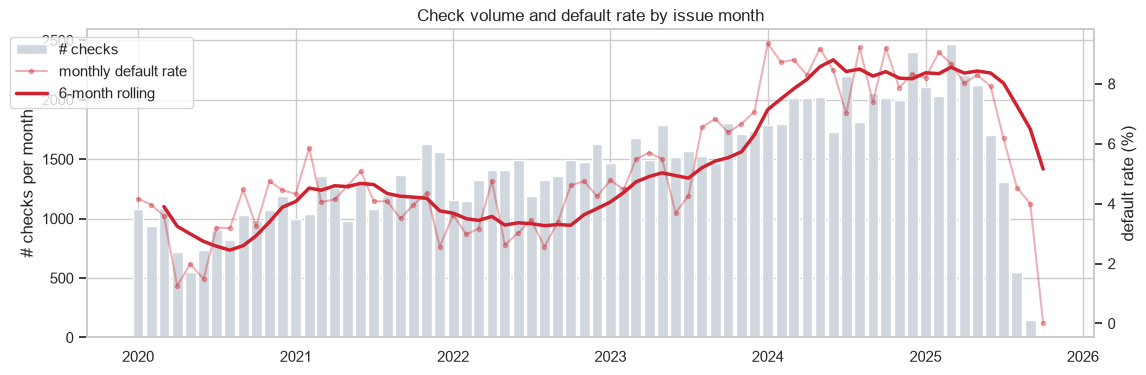

In [9]:
monthly = df.groupby("issue_month")["target"].agg(n="size", default_rate="mean")
yearly = df.groupby("issue_year").agg(n=("target", "size"), defaults=("target", "sum"), default_rate=("target", "mean"))
print(yearly.assign(default_rate=lambda t: (t.default_rate * 100).round(2)))

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(monthly.index, monthly["n"], width=25, color="#d0d7de", label="# checks")
ax.set_ylabel("# checks per month")
ax2 = ax.twinx()
ax2.plot(monthly.index, monthly["default_rate"] * 100, color="#cf222e", alpha=.35, marker=".", label="monthly default rate")
ax2.plot(monthly.index, monthly["default_rate"].rolling(6, min_periods=3).mean() * 100, color="#cf222e", lw=2.5, label="6-month rolling")
ax2.set_ylabel("default rate (%)")
ax2.grid(False)
ax.set_title("Check volume and default rate by issue month")
fig.legend(loc="upper left", bbox_to_anchor=(0.06, 0.88))
save("01_default_rate_over_time")
plt.show()

The default rate doubles over time: about 3.5–4% in 2020–2022, 5.7% in 2023, then 8–8.5% in 2024–2025. This matters a lot:
- a random train/test split would look too optimistic, so I'll use an out-of-time split;
- a model trained on older years will under-predict today's risk, so it will need recalibrating.

The drop at the very end of the chart is checked below.

### 2.1 Are the latest months complete?

In [10]:
df["due_date"] = df["issue_month"] + pd.to_timedelta(df["days_due"], unit="D")
print("Latest due date in the data:", df["due_date"].max().date())

recent = df[df["issue_month"] >= "2025-01-01"].groupby("issue_month").agg(
    n=("target", "size"), default_rate=("target", "mean"),
    median_days_due=("days_due", "median"), latest_due=("due_date", "max"))
recent.index = recent.index.strftime("%Y-%m")
recent.round(3)

Latest due date in the data: 2025-10-15


,n,default_rate,median_days_due,latest_due
issue_month,,,,
2025-01,2109,0.082,89.0,2025-09-21
2025-02,2034,0.090,90.0,2025-09-28
2025-03,2468,0.087,94.0,2025-10-05
2025-04,2206,0.080,87.0,2025-10-06
2025-05,2122,0.083,86.0,2025-10-14
2025-06,1705,0.079,75.0,2025-10-14
2025-07,1312,0.062,64.0,2025-10-15
2025-08,551,0.045,45.0,2025-10-15
2025-09,150,0.040,28.0,2025-10-15


No check is due after 2025-10-15, so the data only contains checks that had already reached their due date. For the last few issue months, only short-term checks qualify, and those are safer, so their default rate looks artificially low.

Decision: I exclude issue months from 2025-06 onwards from the test set.

                    n  default_rate  share
branch_segment                            
A               66227          5.32   66.2
B                5308          7.10    5.3
C               14604          6.16   14.6
D               13861          7.71   13.9


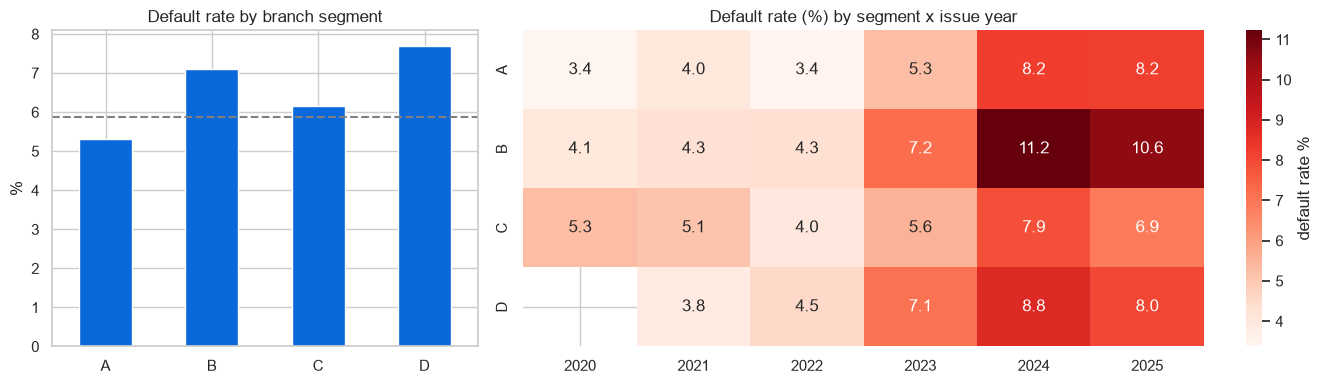

Segment mix by issue year (% of checks):


branch_segment     A    B     C     D
issue_year                           
2020            89.1  6.4   4.4   0.0
2021            82.0  6.2   9.2   2.6
2022            72.6  5.3  14.5   7.6
2023            63.4  5.2  18.2  13.3
2024            55.3  5.3  17.7  21.6
2025            47.1  3.6  18.4  30.9


In [11]:
seg = df.groupby("branch_segment").agg(n=("target", "size"), default_rate=("target", "mean"))
seg["share"] = seg["n"] / len(df)
print(seg.assign(default_rate=lambda t: (t.default_rate * 100).round(2), share=lambda t: (t.share * 100).round(1)))

fig, axes = plt.subplots(1, 2, figsize=(14, 4), gridspec_kw={"width_ratios": [1, 2]})
(seg["default_rate"] * 100).plot.bar(ax=axes[0], color="#0969da", rot=0)
axes[0].axhline(base_rate * 100, ls="--", color="grey")
axes[0].set(title="Default rate by branch segment", ylabel="%", xlabel="")
sns.heatmap(df.pivot_table(index="branch_segment", columns="issue_year", values="target") * 100,
            annot=True, fmt=".1f", cmap="Reds", ax=axes[1], cbar_kws={"label": "default rate %"})
axes[1].set(title="Default rate (%) by segment x issue year", xlabel="", ylabel="")
plt.tight_layout()
save("02_segment_default")
plt.show()

print("Segment mix by issue year (% of checks):")
print((pd.crosstab(df["issue_year"], df["branch_segment"], normalize="index") * 100).round(1))

Pooled over all years, D looks riskiest. But D grows from 0% to 31% of volume and sits mostly in the bad years. Within the same year, D is about as risky as A (8.0% vs 8.2% in 2025). Risk goes up in every segment, so the rise isn't caused by the segment mix.

## 3. Missing values
I check whether a missing value itself says something about default risk.

In [12]:
miss_cols = [c for c in df.columns if df[c].isna().any()]
rows = []
for c in miss_cols:
    m = df[c].isna()
    rows.append({"feature": c, "pct_missing": m.mean() * 100,
                 "default_rate_if_missing": df.loc[m, "target"].mean() * 100,
                 "default_rate_if_present": df.loc[~m, "target"].mean() * 100})
miss = pd.DataFrame(rows).set_index("feature").sort_values("pct_missing", ascending=False)
miss["missing_vs_present"] = miss["default_rate_if_missing"] / miss["default_rate_if_present"]
miss.round(2)

,pct_missing,default_rate_if_missing,default_rate_if_present,missing_vs_present
feature,,,,
drawer_last_redflag_date,97.95,5.75,11.75,0.49
drawer_unpaid_ratio,85.48,5.66,7.12,0.79
drawer_creditbureauscore,74.90,6.13,5.08,1.21
cust_late_balance,73.56,5.98,5.56,1.07
founder_age,72.59,6.00,5.51,1.09
company_age,27.56,5.53,6.00,0.92
drawer_max_balance_last12m,1.64,4.14,5.90,0.70
drawer_unpaidcheckcount,0.84,1.43,5.91,0.24
drawer_interest_accumulated,0.68,2.65,5.89,0.45


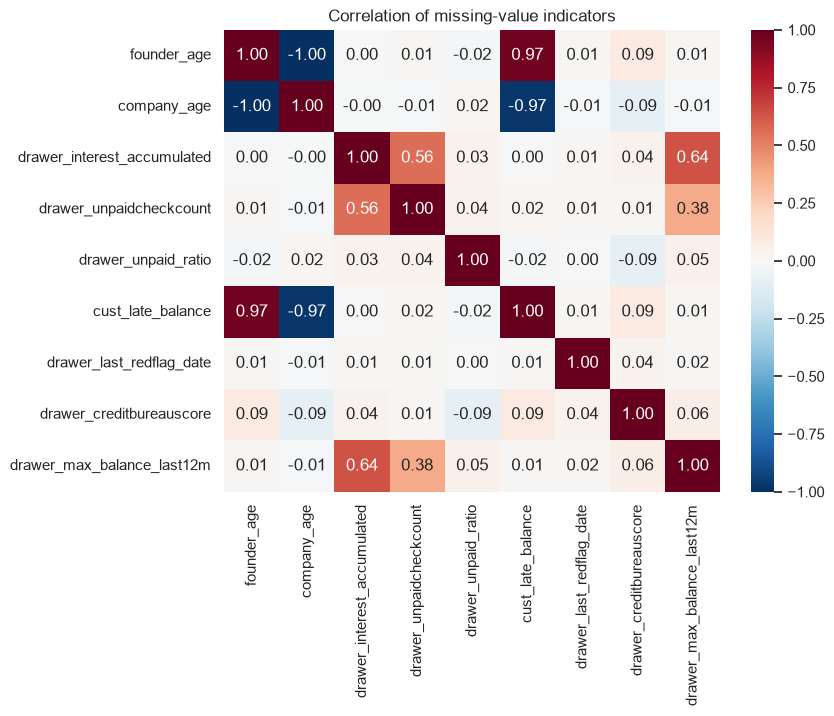

company_age present  False  True 
founder_age present              
False                  146  72445
True                 27409      0


In [13]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(df[miss_cols].isna().corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlation of missing-value indicators")
save("03_missingness_correlation")
plt.show()

print(pd.crosstab(df["founder_age"].notna(), df["company_age"].notna(),
                  rownames=["founder_age present"], colnames=["company_age present"]))

- `founder_age` and `company_age` are never both present: a check comes from either a micro business or a company.
- A missing red-flag date means the drawer never defaulted. When it's present, the default rate doubles (11.8% vs 5.8%).
- A missing drawer history (unpaid count, interest, max balance) means much lower risk, probably new drawers.
- The credit score is missing for 75% of checks.

Missing values carry signal, so I won't fill them with the mean or median. LightGBM handles NaN itself, and in the scorecard missing gets its own bin.

In [14]:
df["is_micro"] = df["founder_age"].notna().astype(int)
print(df.groupby("is_micro")["target"].agg(n="size", default_rate="mean").round(4))
print()
print("Coverage of key fields by issue year (% present):")
print((df.groupby("issue_year")[["drawer_creditbureauscore", "drawer_unpaid_ratio", "drawer_last_redflag_date", "cust_late_balance"]]
       .apply(lambda g: g.notna().mean() * 100)).round(1))

              n  default_rate
is_micro                     
0         72591        0.0600
1         27409        0.0551

Coverage of key fields by issue year (% present):
            drawer_creditbureauscore  drawer_unpaid_ratio  drawer_last_redflag_date  cust_late_balance
issue_year                                                                                            
2020                            22.5                 17.4                       1.3               25.7
2021                            23.2                 12.8                       1.7               26.5
2022                            24.9                 12.7                       2.1               25.2
2023                            25.8                 12.1                       2.4               26.1
2024                            26.2                 15.5                       2.1               26.5
2025                            26.5                 17.6                       2.4               28.6


Micro and company checks default at similar rates. Data coverage barely changes over the years.

## 4. Single features

In [15]:
NUM = ["amount", "days_due", "founder_age", "company_age", "cust_tenure", "risk_other_factoring",
       "drawer_interest_accumulated", "drawer_unpaidcheckcount", "drawer_unpaid_ratio", "cust_late_balance",
       "drawer_last_redflag_date", "drawer_creditbureauscore", "drawer_max_balance_last12m"]
MONEY = ["amount", "risk_other_factoring", "drawer_interest_accumulated", "cust_late_balance", "drawer_max_balance_last12m"]

desc = df[NUM].describe(percentiles=[.01, .05, .5, .95, .99]).T
desc["skew"] = df[NUM].skew()
desc["pct_zero"] = (df[NUM] == 0).mean() * 100
desc.round(2)

,count,mean,std,min,1%,5%,50%,95%,99%,max,skew,pct_zero
amount,100000.0,1524583.36,2.094696e+06,2409.64,99993.2,201302.82,1000000.0,4375000.00,9.000000e+06,1.238057e+08,11.74,0.00
days_due,100000.0,100.74,5.074000e+01,-253.00,15.0,31.00,94.0,190.00,2.580000e+02,7.620000e+02,1.07,0.00
founder_age,27409.0,39.71,1.043000e+01,17.00,20.0,24.00,39.0,59.00,6.800000e+01,8.800000e+01,0.57,0.00
company_age,72445.0,7.85,8.960000e+00,0.00,0.0,1.00,5.0,29.00,3.900000e+01,1.240000e+02,2.18,3.32
cust_tenure,100000.0,1067.42,1.030810e+03,0.00,0.0,2.00,749.0,3118.00,4.180000e+03,7.021000e+03,1.27,4.58
risk_other_factoring,100000.0,9636956.97,3.714264e+07,0.00,0.0,0.00,914835.0,39977545.00,1.791080e+08,9.638154e+08,8.85,17.71
drawer_interest_accumulated,99321.0,57745.82,1.844683e+06,0.00,0.0,0.00,0.0,48407.00,4.447850e+05,2.727199e+08,92.29,55.30
drawer_unpaidcheckcount,99159.0,0.05,3.540000e+00,0.00,0.0,0.00,0.0,0.00,0.000000e+00,1.008000e+03,237.92,98.77
drawer_unpaid_ratio,14515.0,0.33,4.200000e-01,0.00,0.0,0.00,0.0,1.00,1.000000e+00,1.000000e+00,0.73,7.66
cust_late_balance,26445.0,8038.64,3.038131e+04,0.00,0.0,0.00,485.0,37542.00,1.128610e+05,1.218334e+06,16.83,10.47


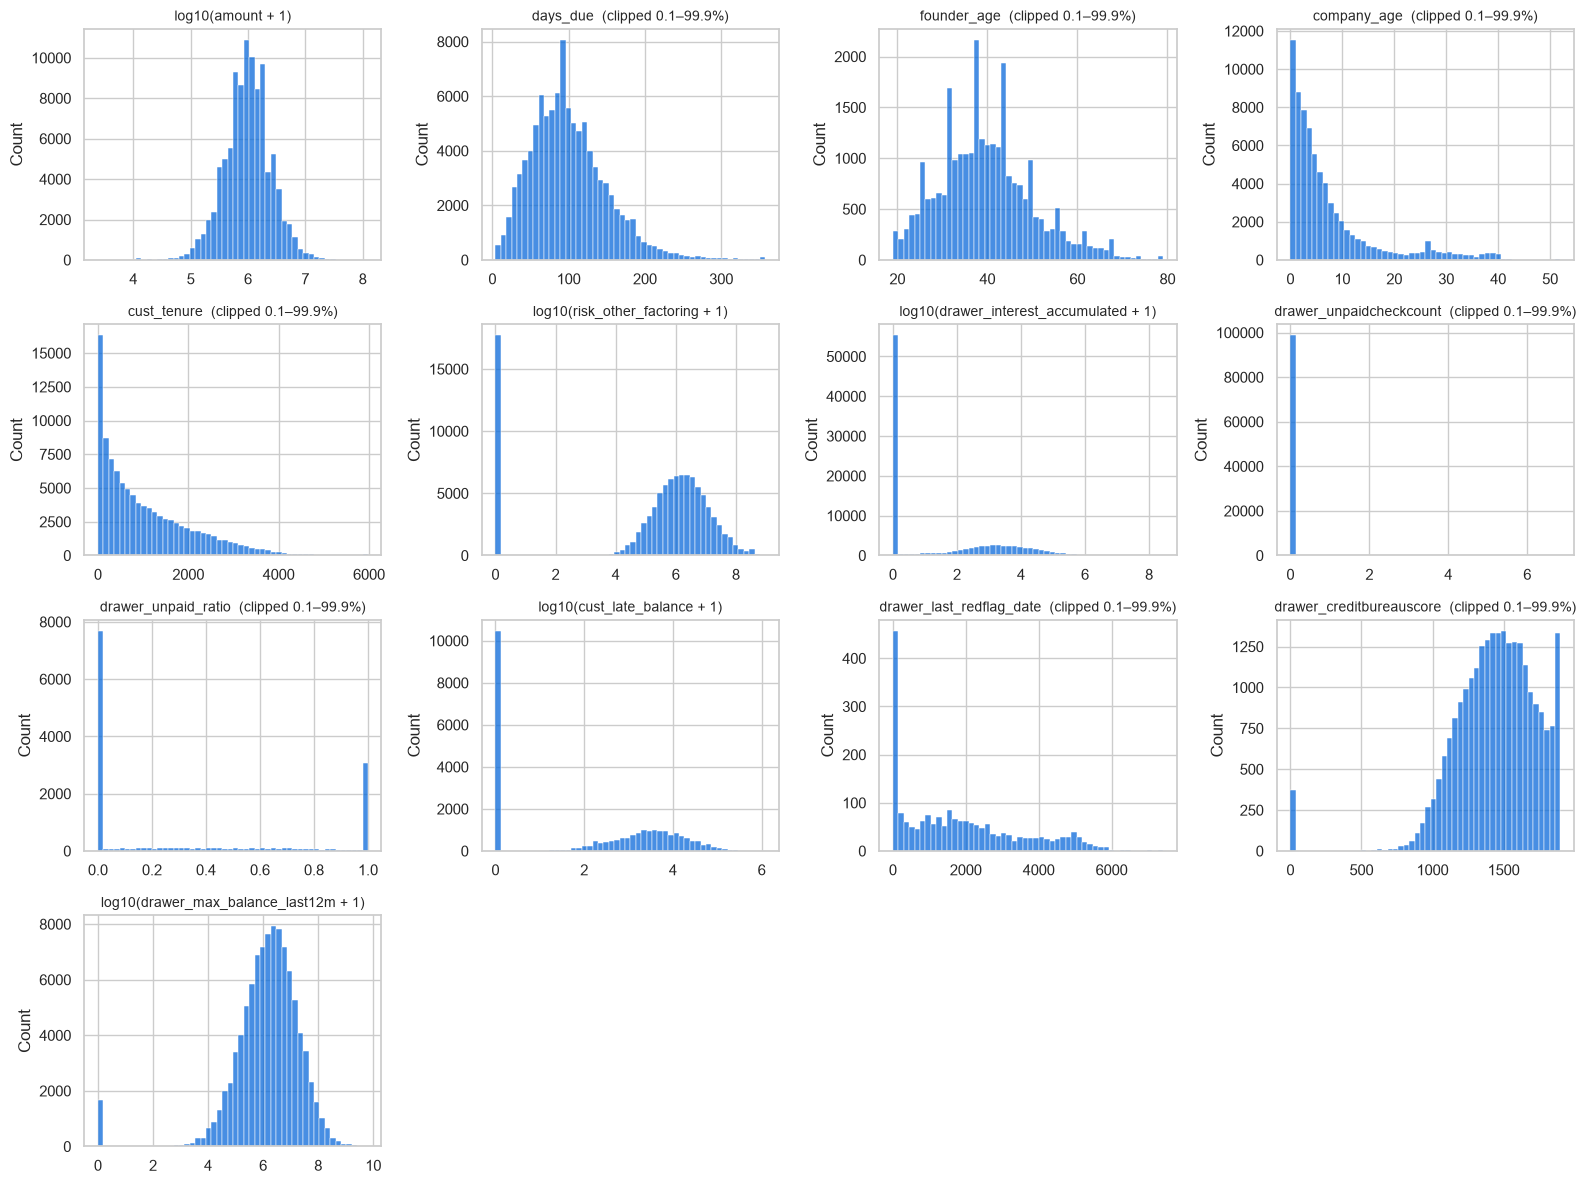

In [16]:
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
for ax, c in zip(axes.flat, NUM):
    x = df[c].dropna()
    if c in MONEY:
        sns.histplot(np.log10(x + 1), bins=50, ax=ax, color="#0969da")
        ax.set_title(f"log10({c} + 1)", fontsize=10)
    else:
        sns.histplot(x.clip(*x.quantile([.001, .999])), bins=50, ax=ax, color="#0969da")
        ax.set_title(c + "  (clipped 0.1–99.9%)", fontsize=10)
    ax.set_xlabel("")
for ax in axes.flat[len(NUM):]:
    ax.remove()
plt.tight_layout()
plt.show()

The money columns are extremely skewed and have many zeros. Logistic regression needs logs or bins for these; tree models don't care.

In [17]:
checks = {
    "days_due < 0 (due before issue)":            (df["days_due"] < 0).sum(),
    "days_due == 0":                              (df["days_due"] == 0).sum(),
    "days_due > 365":                             (df["days_due"] > 365).sum(),
    "drawer_creditbureauscore == 0":              (df["drawer_creditbureauscore"] == 0).sum(),
    "drawer_unpaidcheckcount > 10":               (df["drawer_unpaidcheckcount"] > 10).sum(),
    "company_age >= 100":                         (df["company_age"] >= 100).sum(),
    "founder_age < 18":                           (df["founder_age"] < 18).sum(),
    "first_offer_flag = 1 but cust_tenure > 0":   ((df["cust_first_offer_flag"] == 1) & (df["cust_tenure"] > 0)).sum(),
    "unpaid_ratio > 0 but unpaidcheckcount == 0": ((df["drawer_unpaid_ratio"] > 0) & (df["drawer_unpaidcheckcount"] == 0)).sum(),
}
pd.Series(checks, name="rows").to_frame()

,rows
days_due < 0 (due before issue),7
days_due == 0,2
days_due > 365,81
drawer_creditbureauscore == 0,370
drawer_unpaidcheckcount > 10,77
company_age >= 100,3
founder_age < 18,1
first_offer_flag = 1 but cust_tenure > 0,1751
unpaid_ratio > 0 but unpaidcheckcount == 0,6809


In [18]:
cbs = df["drawer_creditbureauscore"]
print("Default rate | credit score == 0     :", round(df.loc[cbs == 0, "target"].mean(), 4))
print("Default rate | credit score 1–1000   :", round(df.loc[cbs.between(1, 1000), "target"].mean(), 4))
print("Default rate | credit score missing  :", round(df.loc[cbs.isna(), "target"].mean(), 4))
print()
print("cust_tenure (days) when cust_first_offer_flag == 1:")
print(df.loc[df.cust_first_offer_flag == 1, "cust_tenure"].describe(percentiles=[.5, .72, .75, .9]).round(0))

Default rate | credit score == 0     : 0.073
Default rate | credit score 1–1000   : 0.1406
Default rate | credit score missing  : 0.0613

cust_tenure (days) when cust_first_offer_flag == 1:
count    6334.0
mean      269.0
std       726.0
min         0.0
50%         0.0
72%         0.0
75%        13.0
90%       929.0
max      5475.0
Name: cust_tenure, dtype: float64


Data issues:
- 7 checks have negative `days_due` → set to NaN.
- 370 credit scores of 0 → a "no score" code (their default rate is half that of real low scores), set to NaN.
- Unpaid ratio > 0 while unpaid count = 0 in about 6.8k rows, so the two must be defined differently. A question for the data owners.
- Some customers are flagged "first offer" but have tenure > 0; probably different definitions.

### 4.1 Default rate by bins
Each feature split into about 10 bins plus a Missing bin (grey). The red line is the average.

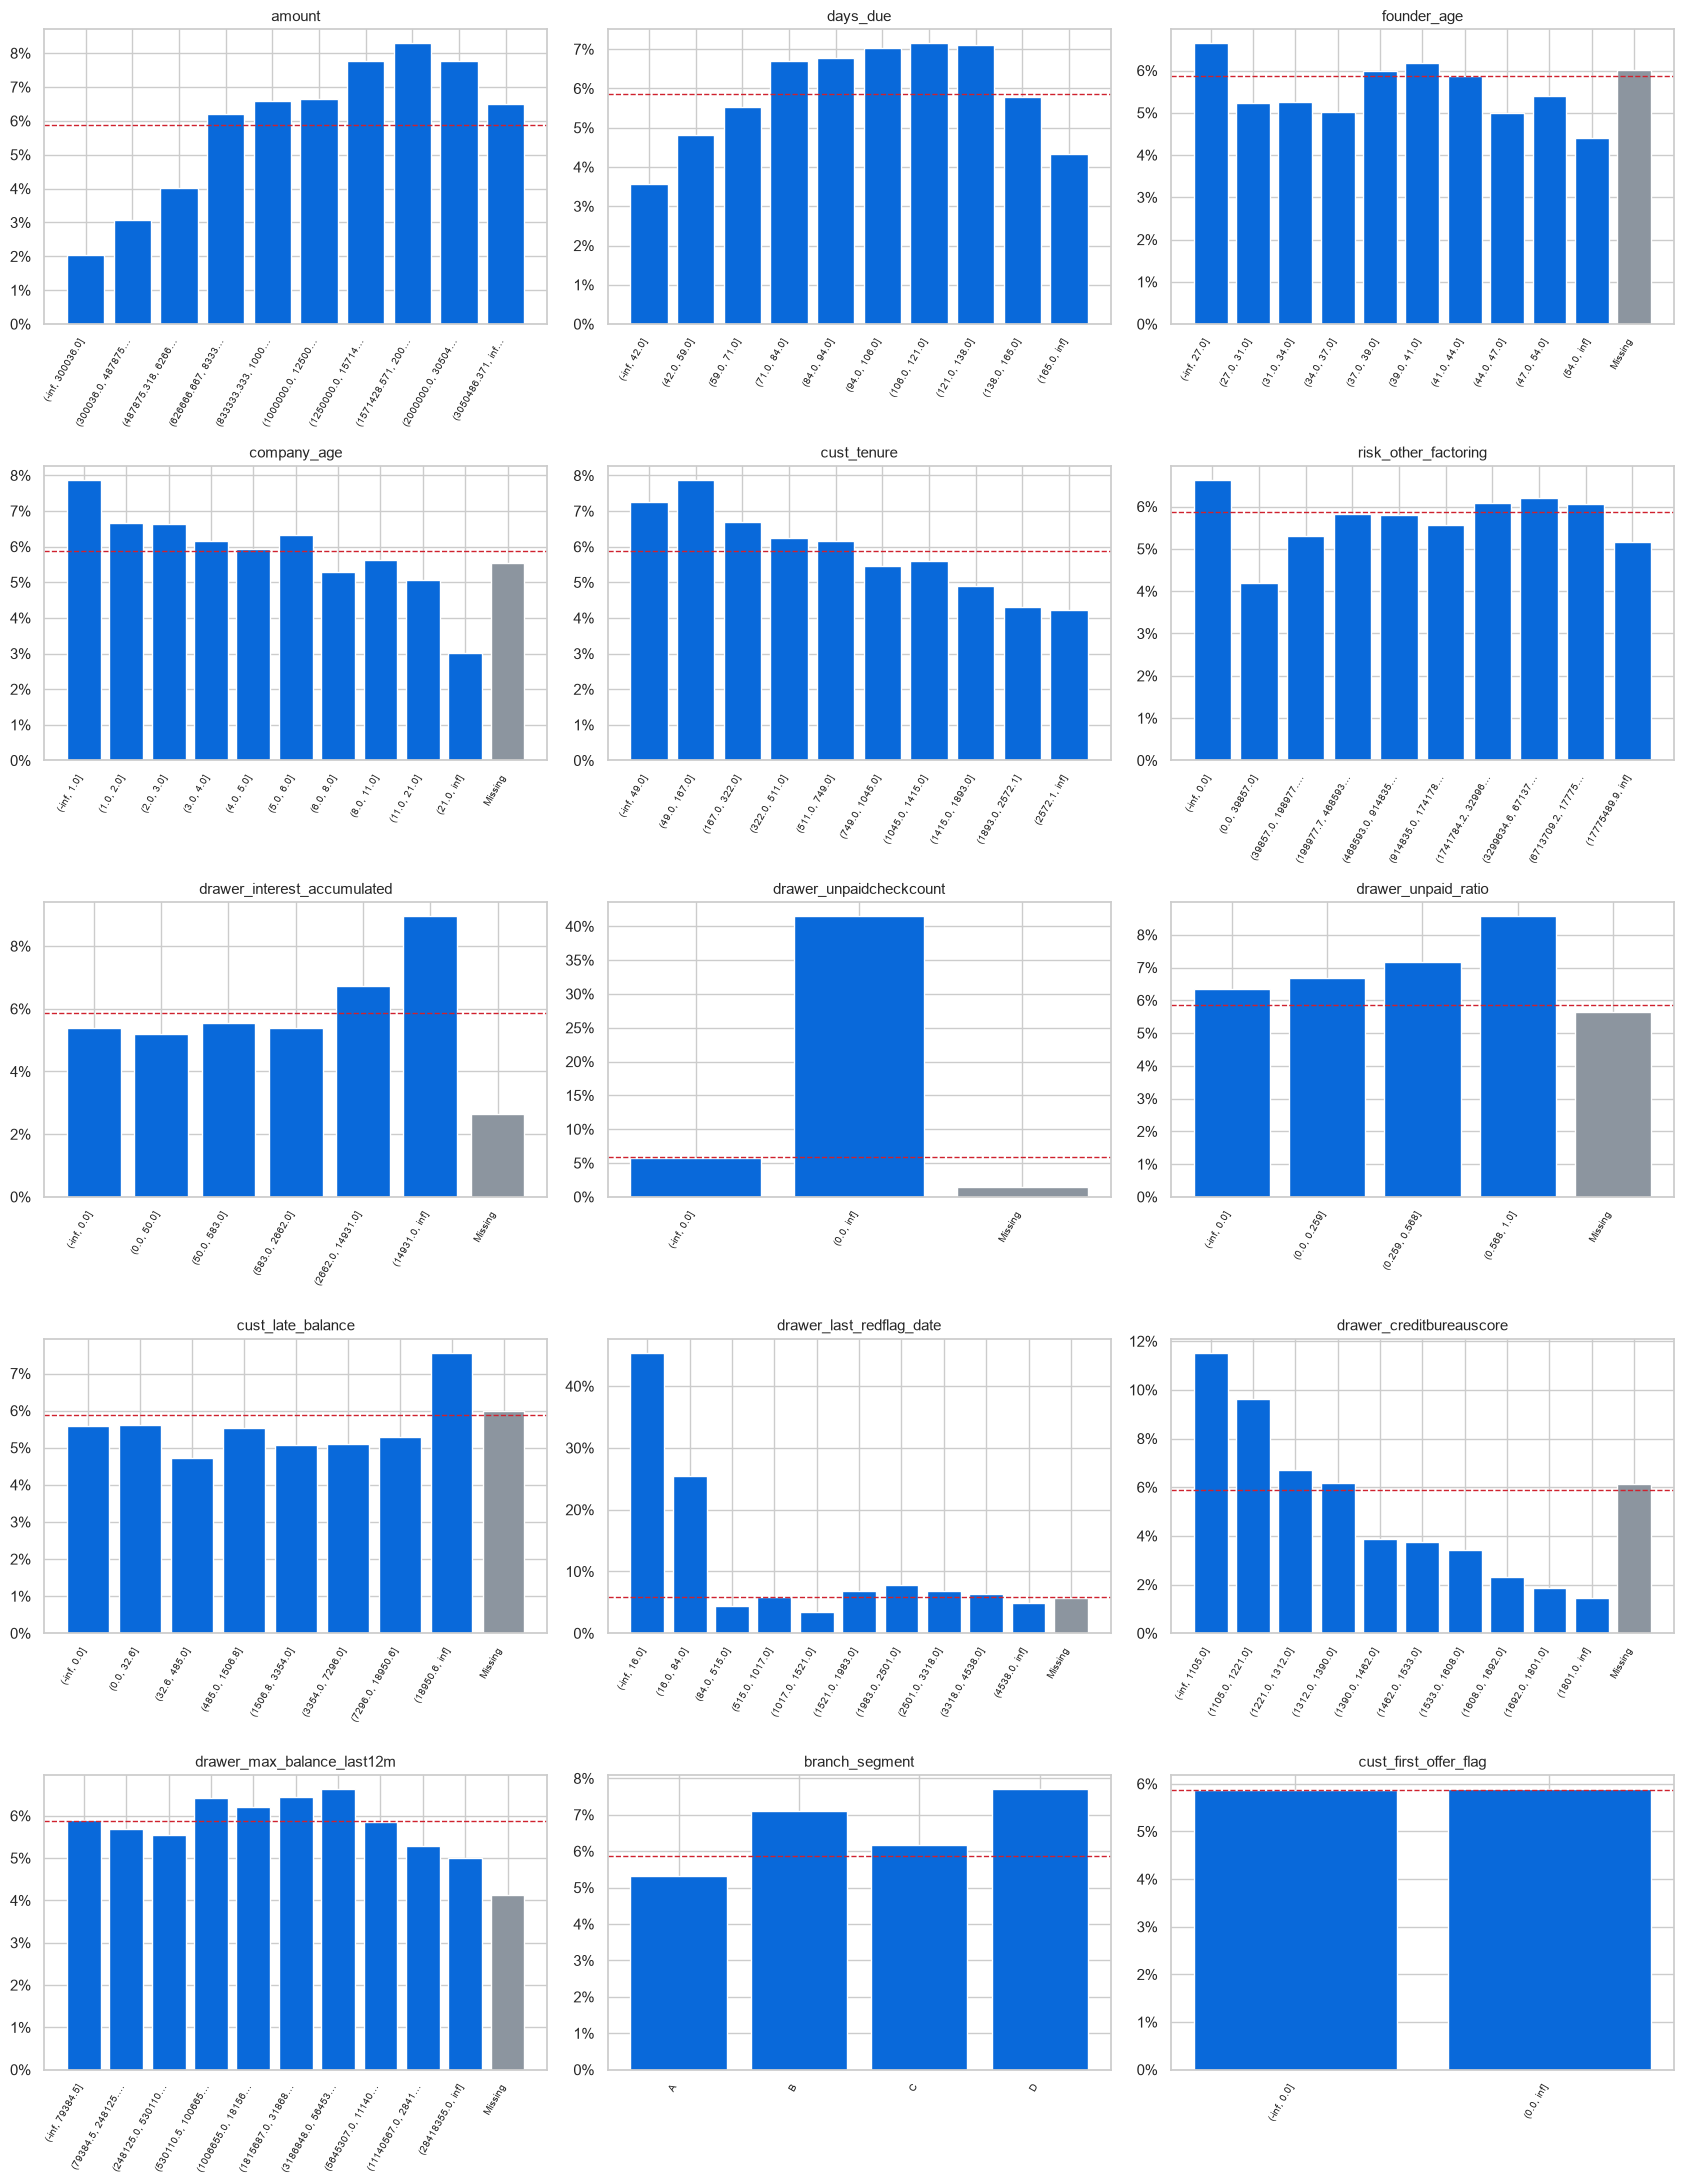

In [19]:
def make_bins(x, q=10, edges=None):
    # Quantile bins with right-closed edges; a zero-inflated feature automatically gets its own "<= 0" bin.
    # Missing values always get their own "Missing" bin.
    if edges is None:
        inner = np.unique(x.dropna().quantile(np.linspace(0, 1, q + 1)[1:-1]).values)
        edges = np.r_[-np.inf, inner, np.inf]
    b = pd.cut(x, edges, right=True, include_lowest=True).astype(str)
    return b.where(x.notna(), "Missing"), edges


def bin_table(x, y, q=10):
    if x.dtype == object or str(x.dtype) in ("category", "str", "string"):
        b = x.astype(str).fillna("Missing")
    else:
        b, _ = make_bins(x, q)
    t = pd.DataFrame({"bin": b, "y": y}).groupby("bin", sort=False)["y"].agg(n="size", bads="sum")
    # Keep numeric order for interval labels, Missing last.
    order = sorted([i for i in t.index if i != "Missing"],
                   key=lambda s: float(s.split(",")[0].strip("([")) if s[0] in "([" else s)
    t = t.loc[order + (["Missing"] if "Missing" in t.index else [])]
    t["default_rate"] = t["bads"] / t["n"]
    return t


fig, axes = plt.subplots(5, 3, figsize=(17, 22))
for ax, c in zip(axes.flat, NUM + ["branch_segment", "cust_first_offer_flag"]):
    t = bin_table(df[c], df["target"])
    colors = ["#8c959f" if i == "Missing" else "#0969da" for i in t.index]
    ax.bar(range(len(t)), t["default_rate"] * 100, color=colors)
    ax.axhline(base_rate * 100, ls="--", color="#cf222e", lw=1)
    ax.set_xticks(range(len(t)))
    ax.set_xticklabels([i if len(i) < 18 else i[:17] + "…" for i in t.index], rotation=60, ha="right", fontsize=7)
    ax.set_title(c, fontsize=11)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
plt.tight_layout()
save("04_default_rate_by_bin")
plt.show()

- Credit score: clean decrease, from 11.5% to 1.4%.
- Red flag in the last ~2 weeks: about 45% default; any unpaid check: about 41%.
- Amount: risk rises from 2% to about 8%.
- Tenure and company age: older means safer.
- `days_due`: an inverted U (short and very long terms are safer).
- First-offer flag, other-factoring risk and founder age: basically flat.

Most relationships are monotonic, so I'll use monotonic constraints in LightGBM.

## 5. Predictive power
- **WoE** for a bin = ln(%good / %bad). Positive means safer than average.
- **IV** sums this up per feature: < 0.02 useless, 0.02–0.1 weak, 0.1–0.3 medium, > 0.5 suspicious.
- **Gini** here = how well the feature ranks checks on its own.

In [20]:
def woe_iv(x, y, q=10, eps=0.5):
    t = bin_table(x, y, q)
    t["goods"] = t["n"] - t["bads"]
    pg = (t["goods"] + eps) / (t["goods"].sum() + eps * len(t))
    pb = (t["bads"] + eps) / (t["bads"].sum() + eps * len(t))
    t["woe"] = np.log(pg / pb)
    t["iv"] = (pg - pb) * t["woe"]
    return t


def woe_transform(x, y, q=10):
    t = woe_iv(x, y, q)
    b = x.astype(str).fillna("Missing") if x.dtype == object or str(x.dtype) in ("category", "str", "string") else make_bins(x, q)[0]
    return b.map(t["woe"]).astype(float)


def iv_label(v):
    return ("useless" if v < .02 else "weak" if v < .1 else "medium" if v < .3 else "strong" if v < .5 else "suspicious")


def screen(frame, features, y):
    rows = []
    for c in features:
        iv = woe_iv(frame[c], y)["iv"].sum()
        gini = 2 * roc_auc_score(y, -woe_transform(frame[c], y)) - 1
        rows.append({"feature": c, "IV": iv, "gini_%": gini * 100, "strength": iv_label(iv),
                     "pct_missing": frame[c].isna().mean() * 100})
    return pd.DataFrame(rows).set_index("feature").sort_values("IV", ascending=False)


RAW_FEATURES = NUM + ["branch_segment", "cust_first_offer_flag", "is_micro"]
iv_raw = screen(df, RAW_FEATURES, df["target"])
iv_raw.round(3)

,IV,gini_%,strength,pct_missing
feature,,,,
amount,0.165,19.729,medium,0.000
drawer_creditbureauscore,0.111,12.097,medium,74.900
drawer_unpaidcheckcount,0.072,3.185,weak,0.841
days_due,0.053,12.215,weak,0.000
drawer_last_redflag_date,0.053,2.558,weak,97.949
company_age,0.045,10.520,weak,27.555
cust_tenure,0.044,11.829,weak,0.000
drawer_interest_accumulated,0.037,8.094,weak,0.679
branch_segment,0.023,7.345,weak,0.000


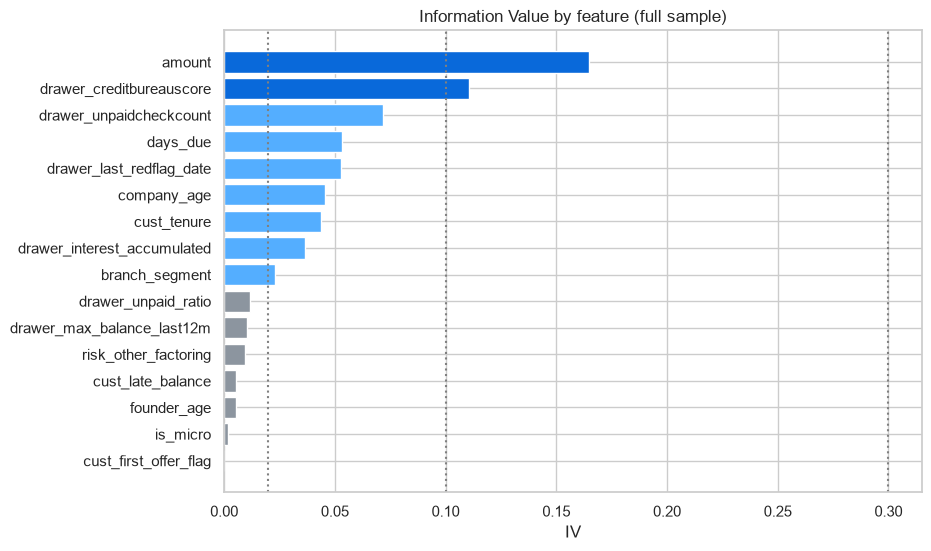

In [21]:
fig, ax = plt.subplots(figsize=(9, 6))
palette = {"useless": "#8c959f", "weak": "#54aeff", "medium": "#0969da", "strong": "#0a3069", "suspicious": "#cf222e"}
ax.barh(iv_raw.index[::-1], iv_raw["IV"][::-1], color=[palette[s] for s in iv_raw["strength"][::-1]])
for v in [.02, .1, .3]:
    ax.axvline(v, ls=":", color="grey")
ax.set_title("Information Value by feature (full sample)")
ax.set_xlabel("IV")
save("05_information_value")
plt.show()

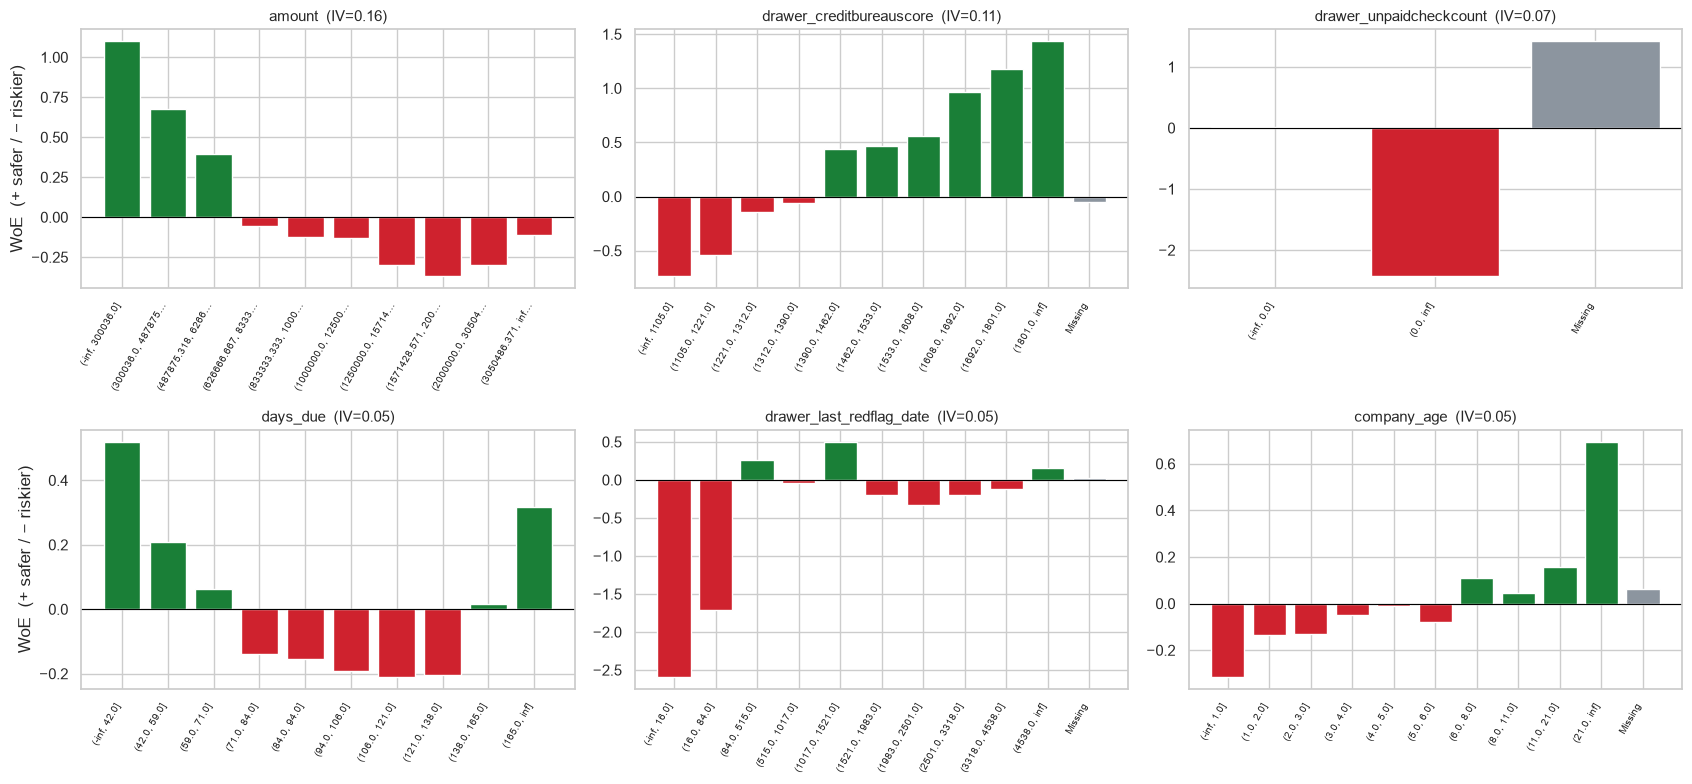

In [22]:
top = iv_raw.index[:6]
fig, axes = plt.subplots(2, 3, figsize=(17, 8))
for ax, c in zip(axes.flat, top):
    t = woe_iv(df[c], df["target"])
    ax.bar(range(len(t)), t["woe"], color=["#8c959f" if i == "Missing" else ("#1a7f37" if w > 0 else "#cf222e") for i, w in zip(t.index, t["woe"])])
    ax.set_xticks(range(len(t)))
    ax.set_xticklabels([i if len(i) < 18 else i[:17] + "…" for i in t.index], rotation=60, ha="right", fontsize=7)
    ax.set_title(f"{c}  (IV={t['iv'].sum():.2f})", fontsize=11)
    ax.axhline(0, color="black", lw=.8)
axes.flat[0].set_ylabel("WoE  (+ safer / − riskier)")
axes.flat[3].set_ylabel("WoE  (+ safer / − riskier)")
plt.tight_layout()
save("06_woe_top_features")
plt.show()

- Only `amount` (IV 0.17) and credit score (0.11) are "medium".
- Drawer history has decent IV but a Gini of only about 3%: it flags a few checks strongly and says nothing about the rest.
- `days_due`, tenure and company age are weak but rank broadly (Gini 10–12%).
- First-offer flag, unpaid ratio, other-factoring risk, late balance and founder age are useless.
- Nothing looks suspiciously strong.

Every feature is weak on its own, so I expect a moderate Gini from the model.

## 6. Correlations & new features

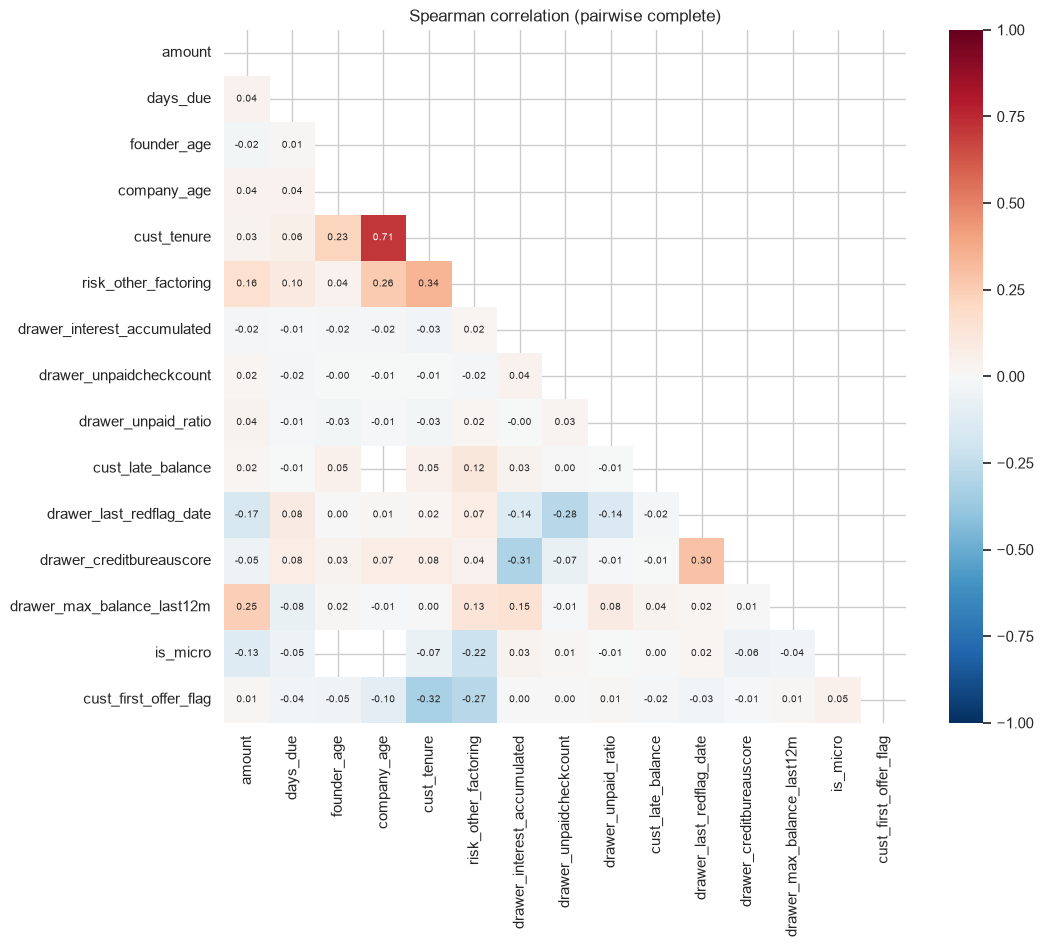

,level_0,level_1,rho
63,cust_tenure,company_age,0.712026


In [23]:
corr = df[NUM + ["is_micro", "cust_first_offer_flag"]].corr(method="spearman")
fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax, annot_kws={"size": 7})
ax.set_title("Spearman correlation (pairwise complete)")
save("07_correlation")
plt.show()

pairs = corr.where(~mask).stack().rename("rho").reset_index()
pairs.loc[pairs["rho"].abs() > .4].sort_values("rho", key=abs, ascending=False)

Features are mostly independent. The only strong pair is tenure vs company age (0.71). No multicollinearity issue.

In [24]:
def safe_div(a, b):
    return (a / b).replace([np.inf, -np.inf], np.nan)


df["owner_or_company_age"] = df["founder_age"].fillna(df["company_age"])
df["amount_to_drawer_maxbal"] = safe_div(df["amount"], df["drawer_max_balance_last12m"])
df["amount_to_other_factoring"] = safe_div(df["amount"], df["risk_other_factoring"])
df["other_factoring_to_drawer_maxbal"] = safe_div(df["risk_other_factoring"], df["drawer_max_balance_last12m"])
df["late_balance_to_amount"] = safe_div(df["cust_late_balance"], df["amount"])
df["drawer_has_redflag"] = df["drawer_last_redflag_date"].notna().astype(int)
df["redflag_within_90d"] = (df["drawer_last_redflag_date"] <= 90).astype(int)
df["drawer_has_unpaid"] = (df["drawer_unpaidcheckcount"] > 0).astype(int)
df["issue_month_of_year"] = df["issue_month"].dt.month

ENGINEERED = ["owner_or_company_age", "amount_to_drawer_maxbal", "amount_to_other_factoring",
              "other_factoring_to_drawer_maxbal", "late_balance_to_amount", "drawer_has_redflag",
              "redflag_within_90d", "drawer_has_unpaid", "issue_month_of_year"]
iv_eng = screen(df, ENGINEERED, df["target"])
iv_eng.round(3)

,IV,gini_%,strength,pct_missing
feature,,,,
drawer_has_unpaid,0.062,2.533,weak,0.000
redflag_within_90d,0.048,2.203,weak,0.000
owner_or_company_age,0.030,9.619,weak,0.146
amount_to_drawer_maxbal,0.029,9.410,weak,3.325
other_factoring_to_drawer_maxbal,0.020,7.009,useless,3.325
drawer_has_redflag,0.017,2.183,useless,0.000
amount_to_other_factoring,0.016,6.502,useless,17.708
issue_month_of_year,0.006,4.233,useless,0.000
late_balance_to_amount,0.003,1.921,useless,73.555


The simple flags (`drawer_has_unpaid`, `redflag_within_90d`) keep most of the signal. The ratios are weaker than raw `amount`, and as section 7 shows, they also drift, so I won't use them.

## 7. Stability over time
My split: train 2020–2023 · validation 2024 H1 · test 2024-07 → 2025-05 · excluded 2025-06 onwards (incomplete).

In [25]:
def period(d):
    return np.select([d < "2024-01-01", d < "2024-07-01", d < "2025-06-01"], ["train", "valid", "test"], "excluded")


df["split"] = period(df["issue_month"])
df.groupby("split")["target"].agg(n="size", default_rate="mean").loc[["train", "valid", "test", "excluded"]].round(4)

,n,default_rate
split,,
train,61500,0.0436
valid,11366,0.0880
test,23414,0.0828
excluded,3720,0.0664


Validation and test are about twice as risky as train (8–9% vs 4.4%), so calibration will be needed.

**PSI** measures how much a feature's distribution changed compared with train. The usual industry rule of thumb is < 0.1 stable, 0.1–0.25 moderate, > 0.25 major. It's a convention, not a statistical test.

In [26]:
def psi(expected, actual, q=10, eps=1e-4):
    if expected.dtype == object or str(expected.dtype) in ("category", "str", "string"):
        e, a = expected.astype(str).fillna("Missing"), actual.astype(str).fillna("Missing")
    else:
        e, edges = make_bins(expected, q)
        a, _ = make_bins(actual, edges=edges)
    pe = e.value_counts(normalize=True)
    pa = a.value_counts(normalize=True).reindex(pe.index.union(a.unique()), fill_value=0)
    pe = pe.reindex(pa.index, fill_value=0) + eps
    pa = pa + eps
    return float(((pa - pe) * np.log(pa / pe)).sum())


FEATURES = RAW_FEATURES + ENGINEERED
PSI_FEATURES = [c for c in FEATURES if c != "issue_month_of_year"]  # calendar month is time by construction
tr, va, te = (df[df["split"] == s] for s in ["train", "valid", "test"])
psi_tbl = pd.DataFrame({
    "PSI train→valid": {c: psi(tr[c], va[c]) for c in PSI_FEATURES},
    "PSI train→test": {c: psi(tr[c], te[c]) for c in PSI_FEATURES},
}).sort_values("PSI train→test", ascending=False)
psi_tbl["status"] = pd.cut(psi_tbl["PSI train→test"], [-1, .1, .25, 99], labels=["stable", "moderate", "MAJOR"])
psi_tbl.round(3)

,PSI train→valid,PSI train→test,status
branch_segment,0.177,0.400,MAJOR
amount_to_drawer_maxbal,0.255,0.387,MAJOR
risk_other_factoring,0.300,0.379,MAJOR
drawer_max_balance_last12m,0.194,0.375,MAJOR
amount_to_other_factoring,0.330,0.354,MAJOR
drawer_interest_accumulated,0.123,0.284,MAJOR
days_due,0.066,0.137,moderate
cust_late_balance,0.039,0.085,stable
late_balance_to_amount,0.033,0.063,stable
cust_tenure,0.034,0.062,stable


In [27]:
by_year = df.groupby("issue_year").agg(
    median_amount=("amount", "median"),
    median_drawer_max_balance=("drawer_max_balance_last12m", "median"),
    median_risk_other_factoring=("risk_other_factoring", "median"),
    median_amount_to_drawer_maxbal=("amount_to_drawer_maxbal", "median"),
    median_amount_to_other_factoring=("amount_to_other_factoring", "median"),
    pct_interest_accum_zero=("drawer_interest_accumulated", lambda s: (s == 0).mean() * 100),
    median_days_due=("days_due", "median"),
    pct_segment_D=("branch_segment", lambda s: (s == "D").mean() * 100),
)
by_year.round(2)

,median_amount,median_drawer_max_balance,median_risk_other_factoring,median_amount_to_drawer_maxbal,median_amount_to_other_factoring,pct_interest_accum_zero,median_days_due,pct_segment_D
issue_year,,,,,,,,
2020,1000000.00,578550.0,319309.0,1.56,2.13,49.40,111.0,0.00
2021,1000000.00,734710.5,450138.0,1.25,1.45,55.75,109.0,2.62
2022,1002500.00,1062955.0,693285.0,0.85,0.97,60.30,99.0,7.64
2023,972657.14,2125000.0,1081737.0,0.42,0.51,57.48,91.0,13.28
2024,1000000.00,3458536.0,1790000.0,0.27,0.33,53.83,88.0,21.64
2025,987951.81,4521895.0,2027066.0,0.20,0.25,53.25,82.0,30.91


- Stable: amount, tenure, credit score, drawer history.
- Major drift: segment mix (D grows), plus the TL exposure features (drawer max balance up 8×, other-factoring risk up 6×, i.e. inflation).
- The ratios drift because their denominators grow: amount / max balance falls from 1.56 to 0.20.
- Median `amount` stays at about 1M every year, which supports the idea that it was transformed.

The drifting features are also the useless ones, so dropping them costs nothing.

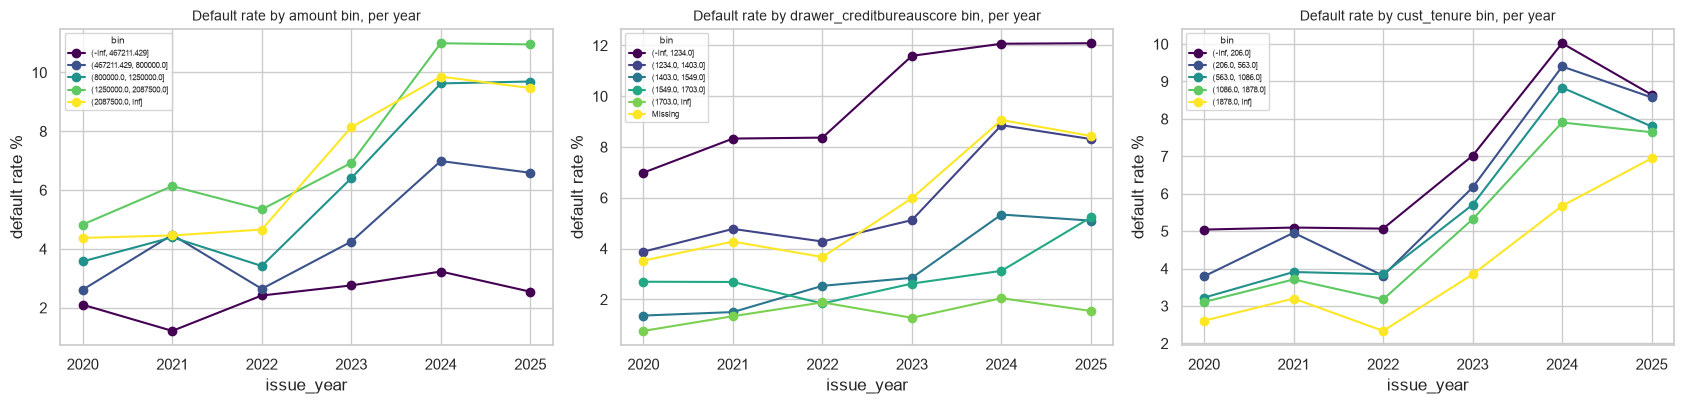

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.2))
for ax, c in zip(axes, ["amount", "drawer_creditbureauscore", "cust_tenure"]):
    b, edges = make_bins(df.loc[df.split == "train", c], q=5)
    bins_all, _ = make_bins(df[c], edges=edges)
    pt = df.assign(b=bins_all).pivot_table(index="b", columns="issue_year", values="target") * 100
    pt = pt.loc[[i for i in bin_table(df.loc[df.split == "train", c], df.loc[df.split == "train", "target"], q=5).index if i in pt.index]]
    pt.T.plot(ax=ax, marker="o", cmap="viridis", legend=True)
    ax.set_title(f"Default rate by {c} bin, per year", fontsize=10)
    ax.set_ylabel("default rate %")
    ax.legend(fontsize=6, title="bin", title_fontsize=7)
plt.tight_layout()
save("08_within_bin_drift")
plt.show()

Default rates rise in almost every bin, but most for the weaker profiles (bigger checks, low or no credit score). Small checks and the best scores barely move. The ranking still holds; only the level changes.

(I picked these three features by judgment; the table below checks all of them.)

### 7.1 Ranking power per year
WoE bins fitted on train, Gini computed per year.

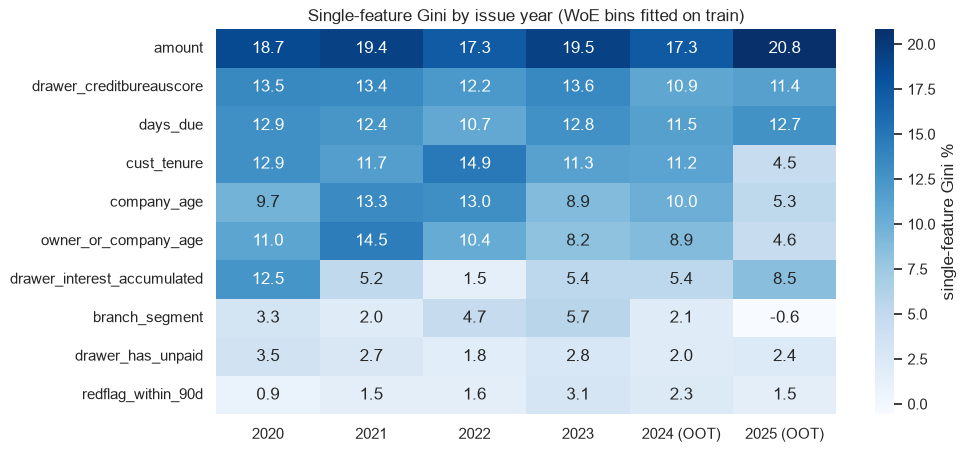

In [29]:
def woe_apply(x_fit, y_fit, x_new, q=10):
    # WoE learned on (x_fit, y_fit), applied to x_new; bins unseen in fit get WoE 0 (= average risk).
    t = woe_iv(x_fit, y_fit, q)
    if x_fit.dtype == object or str(x_fit.dtype) in ("category", "str", "string"):
        b_new = x_new.astype(str).fillna("Missing")
    else:
        _, edges = make_bins(x_fit, q)
        b_new, _ = make_bins(x_new, edges=edges)
    return b_new.map(t["woe"]).astype(float).fillna(0.0)


KEY = ["amount", "drawer_creditbureauscore", "days_due", "cust_tenure", "company_age", "owner_or_company_age",
       "drawer_interest_accumulated", "branch_segment", "drawer_has_unpaid", "redflag_within_90d"]
ev = df[df["split"] != "excluded"]
gini_year = pd.DataFrame({
    c: ev.assign(_w=woe_apply(tr[c], tr["target"], ev[c]))
         .groupby("issue_year").apply(lambda g: (2 * roc_auc_score(g["target"], -g["_w"]) - 1) * 100)
    for c in KEY
}).T
gini_year.columns = [f"{y}{' (OOT)' if y >= 2024 else ''}" for y in gini_year.columns]

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(gini_year, annot=True, fmt=".1f", cmap="Blues", ax=ax, cbar_kws={"label": "single-feature Gini %"})
ax.set(title="Single-feature Gini by issue year (WoE bins fitted on train)", xlabel="", ylabel="")
save("08b_gini_by_year")
plt.show()

- Amount, `days_due` and credit score are stable every year.
- Tenure and company age weaken in 2025 (about 11% → 5%). I'll keep an eye on them.
- Segment and interest accumulated are unstable, so they're candidates to drop.

**Mix shift or risk shift?** A quick model trained on 2020–2021 only. If its predicted default rate rises with the actual one, the features explain the increase. If not, it's a general rise in risk.

            actual  predicted  gini_%          period
issue_year                                           
2020          3.50       3.96   57.71       in-sample
2021          4.15       3.82   64.41       in-sample
2022          3.63       3.53   31.69  OOT, pre-drift
2023          5.66       3.16   36.20      OOT, drift
2024          8.45       3.21   30.17      OOT, drift
2025          7.99       3.04   26.39      OOT, drift


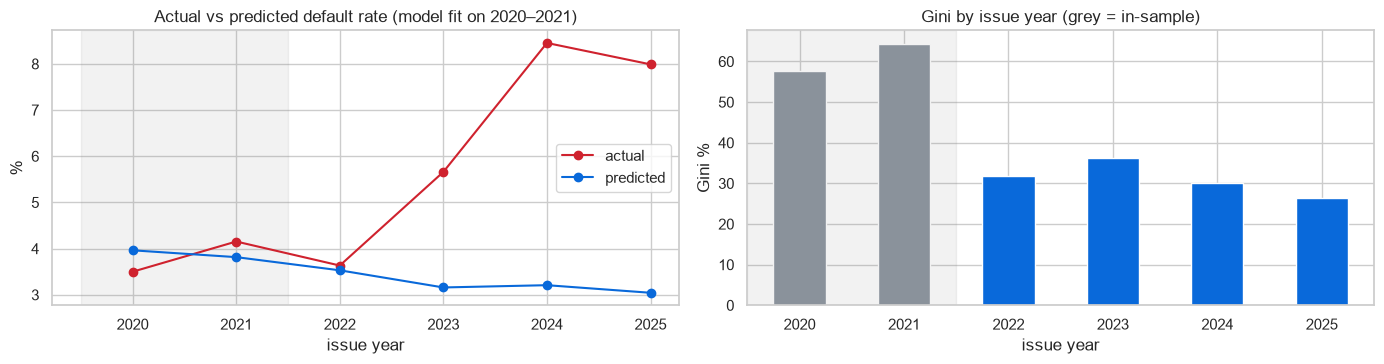

In [30]:
X_COLS = [c for c in FEATURES if c != "issue_month_of_year"]
X = df[X_COLS].copy()
X["branch_segment"] = X["branch_segment"].astype("category")
fit_mask = df["issue_year"] <= 2021

diag = HistGradientBoostingClassifier(max_iter=200, learning_rate=.05, max_leaf_nodes=15, min_samples_leaf=200,
                                      l2_regularization=1.0, categorical_features="from_dtype", random_state=42)
diag.fit(X[fit_mask], df.loc[fit_mask, "target"])
df["_p_diag"] = diag.predict_proba(X)[:, 1]

mix = df.groupby("issue_year").agg(actual=("target", "mean"), predicted=("_p_diag", "mean"))
mix["gini_%"] = df.groupby("issue_year").apply(lambda g: (2 * roc_auc_score(g["target"], g["_p_diag"]) - 1) * 100)
mix["period"] = np.select([mix.index <= 2021, mix.index == 2022], ["in-sample", "OOT, pre-drift"], "OOT, drift")
print(mix.assign(actual=mix.actual * 100, predicted=mix.predicted * 100).round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 3.8))
(mix[["actual", "predicted"]] * 100).plot(ax=axes[0], marker="o", color=["#cf222e", "#0969da"])
axes[0].set(title="Actual vs predicted default rate (model fit on 2020–2021)", ylabel="%", xlabel="issue year")
mix["gini_%"].plot.bar(ax=axes[1], rot=0, color=["#8c959f"] * 2 + ["#0969da"] * 4)
axes[1].set(title="Gini by issue year (grey = in-sample)", ylabel="Gini %", xlabel="issue year")
for ax in axes:
    ax.axvspan(-0.5 if ax is axes[1] else 2019.5, 1.5 if ax is axes[1] else 2021.5, color="grey", alpha=.1)
plt.tight_layout()
save("09_mix_vs_level_shift")
plt.show()
df = df.drop(columns="_p_diag")

- The predicted rate stays around 3% while the actual rate goes up to 8%, so the features don't explain the rise. It's a general level shift.
- Out-of-time Gini is about 32% in 2022 and 26–36% afterwards, so ranking mostly survives.

Takeaways: expect about 30–40% Gini, and recalibrate the probabilities on recent data.

## 8. Leakage check
If the drawer-history features were measured after the check matured, they could include this check's own default.

In [31]:
rf = df["drawer_last_redflag_date"]
recency = pd.cut(rf, [0, 30, 90, 180, 365, 1095, 10_000]).cat.add_categories("never / missing").fillna("never / missing")
print("Default rate by red-flag recency (days):")
print(df.groupby(recency, observed=True)["target"].agg(n="size", default_rate="mean").round(3))
print()
print("Default rate by unpaid check count:")
print(df.groupby(df["drawer_unpaidcheckcount"].clip(upper=3).astype("Int64").astype(str).replace({"3": "3+", "<NA>": "Missing"}))["target"]
      .agg(n="size", default_rate="mean").round(3))

Default rate by red-flag recency (days):


                              n  default_rate
drawer_last_redflag_date                     
(0, 30]                     299         0.418
(30, 90]                    115         0.183
(90, 180]                    69         0.043
(180, 365]                   79         0.051
(365, 1095]                 283         0.057
(1095, 10000]              1206         0.060
never / missing           97949         0.057

Default rate by unpaid check count:
                             n  default_rate
drawer_unpaidcheckcount                     
0                        98766         0.058
1                          157         0.293
2                           52         0.365
3+                         184         0.533


In [32]:
# Test 1: if the check's own default were included, (almost) every defaulted check would have a red flag / unpaid count.
t1 = df.groupby("target").agg(has_redflag=("drawer_has_redflag", "mean"), has_unpaid=("drawer_has_unpaid", "mean")) * 100
print("Test 1 — % of checks with drawer history, by outcome\n", t1.round(2), "\n")

# Test 2: if features were a single snapshot taken at data extraction (~2025-10-15, section 2.1), a defaulted check's
# red-flag recency would track 'days since its own due date', and old issue years would have almost no recent (<=90d) red flags.
days_since_due = (df["due_date"].max() - df["due_date"]).dt.days
d = df["target"].eq(1) & rf.notna()
print(f"Test 2a — corr(red-flag days, days since own due date) among defaulted checks: {np.corrcoef(rf[d], days_since_due[d])[0, 1]:.2f}")
print("Test 2b — % of checks with a red flag <= 90 days old, by issue year:")
print((df.groupby("issue_year")["drawer_last_redflag_date"].apply(lambda s: (s <= 90).mean()) * 100).round(2).to_dict())

Test 1 — % of checks with drawer history, by outcome
         has_redflag  has_unpaid
target                         
0              1.92        0.24
1              4.11        2.78 

Test 2a — corr(red-flag days, days since own due date) among defaulted checks: 0.11
Test 2b — % of checks with a red flag <= 90 days old, by issue year:
{2020: 0.21, 2021: 0.29, 2022: 0.34, 2023: 0.37, 2024: 0.53, 2025: 0.65}


- Only 4% of defaulted checks have a red flag; it would be close to 100% if the outcome leaked in.
- Red-flag recency isn't related to the check's own due date, and recent red flags appear in every year.

So these features look like they're measured at issue date. I keep them, but note it as an assumption.

## 9. Summary

| Topic | Decision |
|---|---|
| `Unnamed: 0`, `TERM` | Drop |
| Time drift | Out-of-time split; recalibrate probabilities |
| Latest months | Exclude issue months from 2025-06 (incomplete) |
| Missing values | Don't fill; NaN for LightGBM, own bin for the scorecard |
| Data errors | Negative `days_due` and credit score 0 → NaN |
| Features | Core: amount, `days_due`, credit score, tenure, company/founder age, drawer history |
| Dropped | First-offer flag, late balance, unpaid ratio, other-factoring risk, max balance, ratios |
| Constraints | Monotonic: credit score ↓, tenure ↓, age ↓, amount ↑, unpaid ↑ |
| Imbalance | Use proper metrics, not accuracy |